# Customer Segmentation Platform — Updated Clustering

This notebook performs a more robust K-Means analysis.

The previous model selected **K=2** with a strong Silhouette Score of approximately **0.7063**, but the resulting clusters were extremely imbalanced (about 98% vs 2%).

This updated notebook therefore:

1. Loads engineered features
2. Validates the data
3. Standardizes features
4. Tests K=2 through K=10
5. Calculates Silhouette Score
6. Calculates cluster-size balance
7. Compares candidate K values
8. Uses multiple diagnostics rather than blindly choosing the highest Silhouette Score
9. Trains the selected final K-Means model
10. Profiles clusters
11. Visualizes clusters with PCA
12. Saves all results

**Important:** The notebook does not automatically force a larger K. It reports the evidence so the final K can be defended.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully")


Libraries loaded successfully


## 2. Load Engineered Dataset

In [2]:
df = pd.read_csv("../outputs/clustering_features.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1000000, 12)


,customer_id,Recency,Frequency,Monetary_Value,Average_Order_Value,Engagement_Score,Discount_Dependency,Return_Rate,Online_Purchase_Ratio,InStore_Purchase_Ratio,Avg_Items_Per_Transaction,Support_Interaction_Rate
0,1,40,690.000000,563.16,8.161739,30,0.02,0.000000,0.797101,1.246377,8.64,0.072464
1,2,338,4.000000,7554.57,944.321250,40,0.33,0.008421,6.000000,0.250000,9.60,0.750000
2,3,61,14.600000,7564.14,103.618356,89,0.47,0.000000,0.219178,0.616438,1.55,0.027397
3,4,42,200.000000,8125.92,406.296000,12,0.41,0.018987,2.500000,2.350000,1.78,0.600000
4,5,242,11.857143,114.32,1.377349,31,0.22,0.007605,0.578313,0.506024,9.38,0.036145


## 3. Basic Data Validation

In [3]:
print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))
print("Missing values:", df.isnull().sum().sum())

numeric_columns = df.select_dtypes(include=np.number).columns

print("Infinite values:", np.isinf(df[numeric_columns]).sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Rows: 1,000,000
Columns: 12
Missing values: 0
Infinite values: 0
Duplicate rows: 0


## 4. Define Clustering Features

In [4]:
clustering_features = [
    "Recency",
    "Frequency",
    "Monetary_Value",
    "Average_Order_Value",
    "Engagement_Score",
    "Discount_Dependency",
    "Return_Rate",
    "Online_Purchase_Ratio",
    "InStore_Purchase_Ratio",
    "Avg_Items_Per_Transaction",
    "Support_Interaction_Rate"
]

missing_features = [
    col for col in clustering_features
    if col not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing clustering features: {missing_features}"
    )

print("Number of clustering features:", len(clustering_features))
print(*clustering_features, sep="\n")


Number of clustering features: 11
Recency
Frequency
Monetary_Value
Average_Order_Value
Engagement_Score
Discount_Dependency
Return_Rate
Online_Purchase_Ratio
InStore_Purchase_Ratio
Avg_Items_Per_Transaction
Support_Interaction_Rate


## 5. Prepare Feature Matrix

In [5]:
customer_ids = df["customer_id"].copy()
X = df[clustering_features].copy()

print("Customer IDs:", len(customer_ids))
print("Feature matrix:", X.shape)


Customer IDs: 1000000
Feature matrix: (1000000, 11)


## 6. Final Numeric Check

In [6]:
print("Data types:")
print(X.dtypes)

print("\nMissing values:", X.isnull().sum().sum())
print("Infinite values:", np.isinf(X).sum().sum())


Data types:
Recency                        int64
Frequency                    float64
Monetary_Value               float64
Average_Order_Value          float64
Engagement_Score               int64
Discount_Dependency          float64
Return_Rate                  float64
Online_Purchase_Ratio        float64
InStore_Purchase_Ratio       float64
Avg_Items_Per_Transaction    float64
Support_Interaction_Rate     float64
dtype: object

Missing values: 0
Infinite values: 0


## 7. Standardize Features

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardization complete.")
print("Scaled shape:", X_scaled.shape)


Standardization complete.
Scaled shape: (1000000, 11)


# K Selection Analysis

We test K=2 through K=10.

For each K we calculate:

- Inertia on the **full dataset**
- Silhouette Score on a **representative sample of up to 10,000 customers**
- Smallest cluster size
- Largest cluster size

Using a sample for Silhouette Score is intentional because the exact calculation becomes extremely expensive on very large datasets. K-Means is still fitted on the full dataset.

## 8. Evaluate K=2 Through K=10

In [8]:
k_values = range(2, 11)

# Silhouette Score is expensive on very large datasets.
# Use a representative sample for Silhouette calculations,
# while fitting K-Means on the FULL dataset for each K.
SILHOUETTE_SAMPLE_SIZE = min(10000, X_scaled.shape[0])

rng = np.random.default_rng(42)
silhouette_indices = rng.choice(
    X_scaled.shape[0],
    size=SILHOUETTE_SAMPLE_SIZE,
    replace=False
)

X_silhouette_sample = X_scaled[silhouette_indices]

results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit K-Means on the complete dataset
    labels = model.fit_predict(X_scaled)

    # Calculate Silhouette Score on the representative sample
    sample_labels = labels[silhouette_indices]

    score = silhouette_score(
        X_silhouette_sample,
        sample_labels
    )

    counts = pd.Series(labels).value_counts()

    smallest_cluster = counts.min()
    largest_cluster = counts.max()

    results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette_Score": score,
        "Smallest_Cluster": smallest_cluster,
        "Largest_Cluster": largest_cluster,
        "Smallest_Cluster_%": smallest_cluster / len(labels) * 100,
        "Largest_Cluster_%": largest_cluster / len(labels) * 100
    })

k_results = pd.DataFrame(results)

print(f"Silhouette sample size: {SILHOUETTE_SAMPLE_SIZE:,}")
k_results

Silhouette sample size: 10,000


,K,Inertia,Silhouette_Score,Smallest_Cluster,Largest_Cluster,Smallest_Cluster_%,Largest_Cluster_%
0,2,8.811125e+06,0.691757,19767,980233,1.9767,98.0233
1,3,8.057828e+06,0.119908,19258,491109,1.9258,49.1109
2,4,7.245603e+06,0.138438,19376,458765,1.9376,45.8765
3,5,6.809194e+06,0.124402,18842,345769,1.8842,34.5769
4,6,6.117361e+06,0.138905,3190,443476,0.3190,44.3476
5,7,5.711256e+06,0.128751,3010,334871,0.3010,33.4871
6,8,5.376277e+06,0.133638,2809,225083,0.2809,22.5083
7,9,5.136189e+06,0.132797,3011,186582,0.3011,18.6582
8,10,4.927407e+06,0.135074,2806,151501,0.2806,15.1501


## 9. Rank K Values by Silhouette Score

In [9]:
k_results.sort_values(
    "Silhouette_Score",
    ascending=False
).reset_index(drop=True)


,K,Inertia,Silhouette_Score,Smallest_Cluster,Largest_Cluster,Smallest_Cluster_%,Largest_Cluster_%
0,2,8.811125e+06,0.691757,19767,980233,1.9767,98.0233
1,6,6.117361e+06,0.138905,3190,443476,0.3190,44.3476
2,4,7.245603e+06,0.138438,19376,458765,1.9376,45.8765
3,10,4.927407e+06,0.135074,2806,151501,0.2806,15.1501
4,8,5.376277e+06,0.133638,2809,225083,0.2809,22.5083
5,9,5.136189e+06,0.132797,3011,186582,0.3011,18.6582
6,7,5.711256e+06,0.128751,3010,334871,0.3010,33.4871
7,5,6.809194e+06,0.124402,18842,345769,1.8842,34.5769
8,3,8.057828e+06,0.119908,19258,491109,1.9258,49.1109


## 10. Elbow Curve

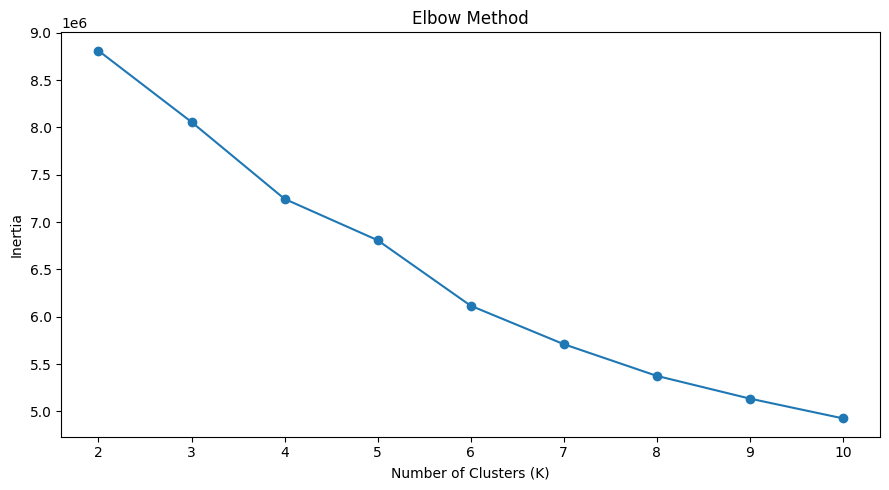

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_results["K"],
    k_results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


## 11. Silhouette Curve

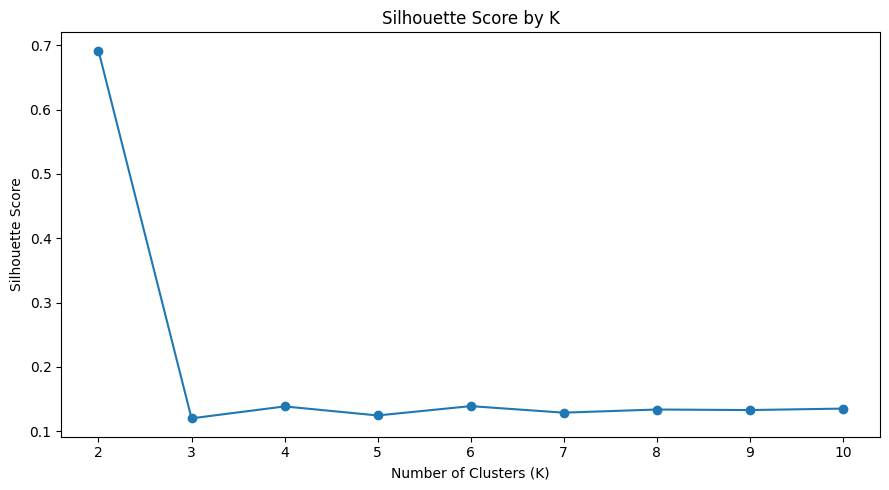

In [11]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_results["K"],
    k_results["Silhouette_Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")

plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


## 12. Cluster Balance Curve

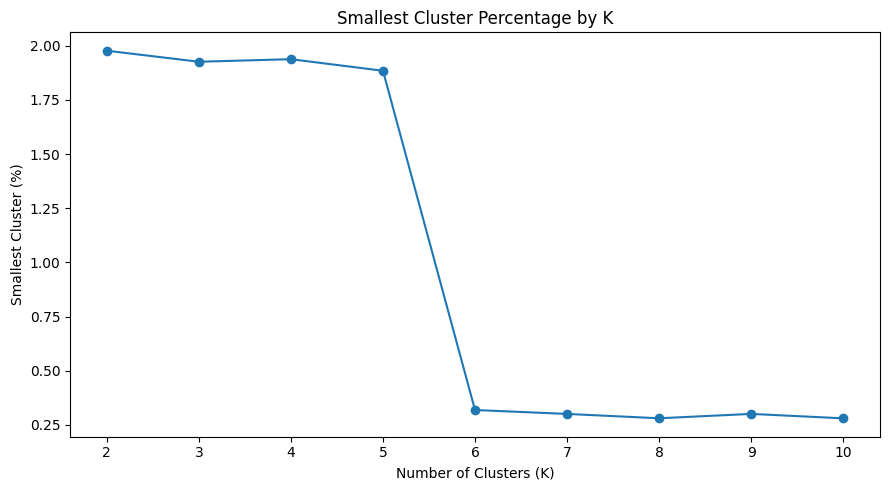

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_results["K"],
    k_results["Smallest_Cluster_%"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Smallest Cluster (%)")
plt.title("Smallest Cluster Percentage by K")

plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


## 13. K Selection Diagnostics

A high Silhouette Score is useful, but a highly imbalanced solution may be less useful for business segmentation.

The table below highlights:

- Statistical separation
- Cluster balance
- Model compactness

Do not blindly choose K based on one metric.


In [13]:
display(
    k_results.style
    .format({
        "Inertia": "{:,.2f}",
        "Silhouette_Score": "{:.4f}",
        "Smallest_Cluster_%": "{:.2f}%",
        "Largest_Cluster_%": "{:.2f}%"
    })
)


,K,Inertia,Silhouette_Score,Smallest_Cluster,Largest_Cluster,Smallest_Cluster_%,Largest_Cluster_%
0,2,"8,811,125.39",0.6918,19767,980233,1.98%,98.02%
1,3,"8,057,828.10",0.1199,19258,491109,1.93%,49.11%
2,4,"7,245,602.55",0.1384,19376,458765,1.94%,45.88%
3,5,"6,809,194.08",0.1244,18842,345769,1.88%,34.58%
4,6,"6,117,361.07",0.1389,3190,443476,0.32%,44.35%
5,7,"5,711,256.39",0.1288,3010,334871,0.30%,33.49%
6,8,"5,376,276.84",0.1336,2809,225083,0.28%,22.51%
7,9,"5,136,188.59",0.1328,3011,186582,0.30%,18.66%
8,10,"4,927,407.07",0.1351,2806,151501,0.28%,15.15%


## 14. Suggested Candidate K Values

For an initial business-segmentation candidate set, we identify K values where the smallest cluster contains at least 5% of customers.

This is **not** a hard mathematical rule. It is a practical diagnostic to avoid extremely tiny segments.


In [14]:
balanced_candidates = k_results[
    k_results["Smallest_Cluster_%"] >= 5
].copy()

print("Candidate K values with smallest cluster >= 5%:")
print(balanced_candidates[[
    "K",
    "Silhouette_Score",
    "Smallest_Cluster_%",
    "Largest_Cluster_%"
]].to_string(index=False))


Candidate K values with smallest cluster >= 5%:
Empty DataFrame
Columns: [K, Silhouette_Score, Smallest_Cluster_%, Largest_Cluster_%]
Index: []


## 15. Recommended K

The recommended K is selected from the balanced candidates by highest Silhouette Score.

If no K satisfies the 5% diagnostic, the notebook falls back to the K with the highest Silhouette Score.

This is a **diagnostic recommendation**, not an automatic claim that the chosen K is the only correct answer.


In [15]:
if len(balanced_candidates) > 0:
    recommended_row = balanced_candidates.loc[
        balanced_candidates["Silhouette_Score"].idxmax()
    ]
else:
    recommended_row = k_results.loc[
        k_results["Silhouette_Score"].idxmax()
    ]

RECOMMENDED_K = int(recommended_row["K"])

print("Recommended K:", RECOMMENDED_K)
print(
    "Silhouette Score:",
    round(recommended_row["Silhouette_Score"], 4)
)
print(
    "Smallest Cluster %:",
    round(recommended_row["Smallest_Cluster_%"], 2)
)
print(
    "Largest Cluster %:",
    round(recommended_row["Largest_Cluster_%"], 2)
)


Recommended K: 2
Silhouette Score: 0.6918
Smallest Cluster %: 1.98
Largest Cluster %: 98.02


## 16. Compare K=2 With Recommended K

This comparison is important because the original model selected K=2.


In [16]:
comparison_k = k_results[
    k_results["K"].isin([2, RECOMMENDED_K])
].copy()

comparison_k


,K,Inertia,Silhouette_Score,Smallest_Cluster,Largest_Cluster,Smallest_Cluster_%,Largest_Cluster_%
0,2,8.811125e+06,0.691757,19767,980233,1.9767,98.0233


# Final K-Means Model

## 17. Set Final K

In [17]:
FINAL_K = RECOMMENDED_K

print("FINAL_K =", FINAL_K)


FINAL_K = 2


## 18. Train Final K-Means

In [18]:
final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

print("Final K-Means model trained successfully.")


Final K-Means model trained successfully.


## 19. Add Cluster Labels

In [19]:
clustered_df = df.copy()
clustered_df["Cluster"] = cluster_labels

clustered_df[
    ["customer_id", "Cluster"]
].head(10)


,customer_id,Cluster
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
5,6,0
6,7,0
7,8,0
8,9,0
9,10,0


## 20. Cluster Distribution

In [20]:
cluster_counts = (
    clustered_df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_distribution = pd.DataFrame({
    "Cluster": cluster_counts.index,
    "Customers": cluster_counts.values
})

cluster_distribution["Percentage"] = (
    cluster_distribution["Customers"]
    / len(clustered_df)
    * 100
).round(2)

cluster_distribution


,Cluster,Customers,Percentage
0,0,980233,98.02
1,1,19767,1.98


## 21. Plot Cluster Sizes

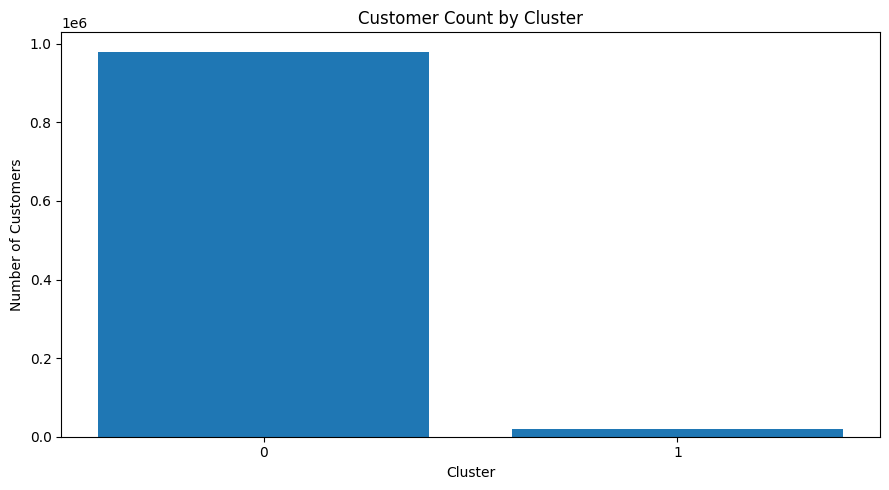

In [21]:
plt.figure(figsize=(9, 5))

plt.bar(
    cluster_distribution["Cluster"].astype(str),
    cluster_distribution["Customers"]
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Count by Cluster")

plt.tight_layout()
plt.show()


# Cluster Profiling

## 22. Cluster Mean Profile

In [22]:
cluster_profile = (
    clustered_df
    .groupby("Cluster")[clustering_features]
    .mean()
    .round(3)
)

cluster_profile


,Recency,Frequency,Monetary_Value,Average_Order_Value,Engagement_Score,Discount_Dependency,Return_Rate,Online_Purchase_Ratio,InStore_Purchase_Ratio,Avg_Items_Per_Transaction,Support_Interaction_Rate
Cluster,,,,,,,,,,,
0,182.015,65.479,5044.660,190.607,49.514,0.25,0.061,1.864,1.865,5.503,0.358
1,182.671,2.035,5621.391,3952.046,49.446,0.25,0.059,38.432,38.475,5.501,7.363


## 23. Cluster Median Profile

In [23]:
cluster_median_profile = (
    clustered_df
    .groupby("Cluster")[clustering_features]
    .median()
    .round(3)
)

cluster_median_profile


,Recency,Frequency,Monetary_Value,Average_Order_Value,Engagement_Score,Discount_Dependency,Return_Rate,Online_Purchase_Ratio,InStore_Purchase_Ratio,Avg_Items_Per_Transaction,Support_Interaction_Rate
Cluster,,,,,,,,,,,
0,182.0,11.333,5042.63,99.195,50.0,0.25,0.018,0.969,0.971,5.50,0.186
1,183.0,0.333,5849.96,3377.370,49.0,0.25,0.018,32.667,33.000,5.51,6.333


## 24. Cluster Profile With Counts

In [24]:
cluster_profile_with_counts = cluster_profile.copy()

cluster_profile_with_counts.insert(
    0,
    "Customers",
    clustered_df["Cluster"].value_counts().sort_index()
)

cluster_profile_with_counts


,Customers,Recency,Frequency,Monetary_Value,Average_Order_Value,Engagement_Score,Discount_Dependency,Return_Rate,Online_Purchase_Ratio,InStore_Purchase_Ratio,Avg_Items_Per_Transaction,Support_Interaction_Rate
Cluster,,,,,,,,,,,,
0,980233,182.015,65.479,5044.660,190.607,49.514,0.25,0.061,1.864,1.865,5.503,0.358
1,19767,182.671,2.035,5621.391,3952.046,49.446,0.25,0.059,38.432,38.475,5.501,7.363


## 25. Standardized Cluster Profile

In [25]:
profile_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

profile_scaled_df["Cluster"] = clustered_df["Cluster"].values

standardized_cluster_profile = (
    profile_scaled_df
    .groupby("Cluster")[clustering_features]
    .mean()
    .round(2)
)

standardized_cluster_profile


,Recency,Frequency,Monetary_Value,Average_Order_Value,Engagement_Score,Discount_Dependency,Return_Rate,Online_Purchase_Ratio,InStore_Purchase_Ratio,Avg_Items_Per_Transaction,Support_Interaction_Rate
Cluster,,,,,,,,,,,
0,-0.00,0.01,-0.0,-0.11,0.0,0.0,0.00,-0.10,-0.1,0.0,-0.10
1,0.01,-0.36,0.2,5.26,-0.0,-0.0,-0.01,5.19,5.2,-0.0,5.16


## 26. Plot Standardized Cluster Profiles

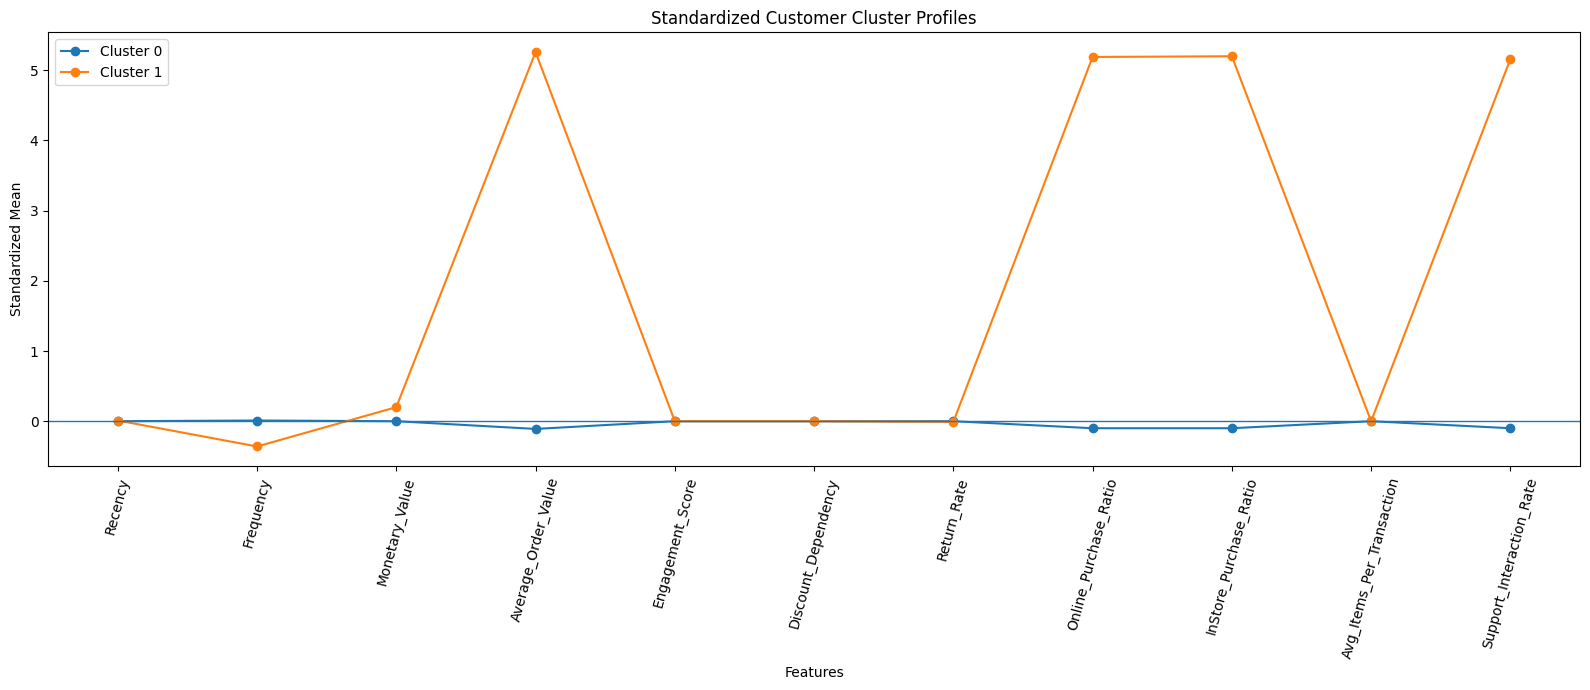

In [26]:
plt.figure(figsize=(16, 7))

for cluster in standardized_cluster_profile.index:
    plt.plot(
        clustering_features,
        standardized_cluster_profile.loc[cluster],
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Features")
plt.ylabel("Standardized Mean")
plt.title("Standardized Customer Cluster Profiles")
plt.xticks(rotation=75)
plt.legend()
plt.tight_layout()
plt.show()


# PCA Visualization

## 27. PCA Projection

In [27]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print(
    "PC1 explained variance:",
    round(pca.explained_variance_ratio_[0], 4)
)

print(
    "PC2 explained variance:",
    round(pca.explained_variance_ratio_[1], 4)
)

print(
    "Total explained variance:",
    round(pca.explained_variance_ratio_.sum(), 4)
)


PC1 explained variance: 0.2863
PC2 explained variance: 0.0947
Total explained variance: 0.381


## 28. PCA Cluster Visualization

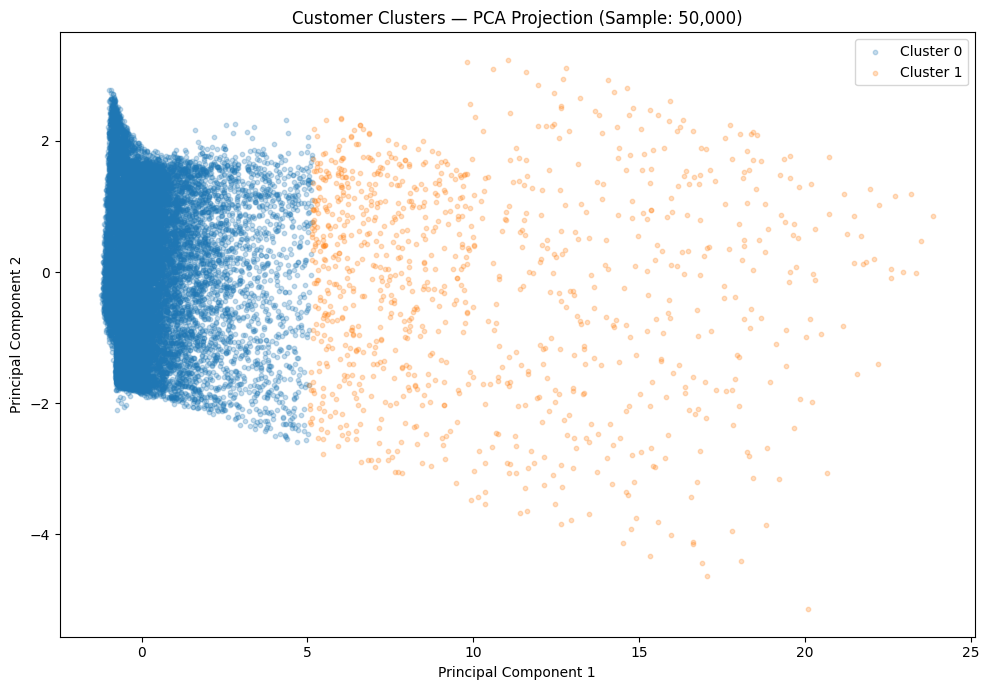

In [28]:
# Plot a representative sample when the dataset is very large.
PCA_PLOT_SAMPLE_SIZE = min(50000, X_pca.shape[0])

rng_pca = np.random.default_rng(42)
pca_plot_indices = rng_pca.choice(
    X_pca.shape[0],
    size=PCA_PLOT_SAMPLE_SIZE,
    replace=False
)

plt.figure(figsize=(10, 7))

plot_clusters = clustered_df["Cluster"].to_numpy()[pca_plot_indices]

for cluster in sorted(clustered_df["Cluster"].unique()):
    mask = plot_clusters == cluster

    plt.scatter(
        X_pca[pca_plot_indices, 0][mask],
        X_pca[pca_plot_indices, 1][mask],
        alpha=0.25,
        s=10,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    f"Customer Clusters — PCA Projection "
    f"(Sample: {PCA_PLOT_SAMPLE_SIZE:,})"
)
plt.legend()
plt.tight_layout()
plt.show()

# Final Evaluation

## 29. Final Silhouette Score

The final K-Means model was trained on the **full dataset**.

For performance, the final Silhouette Score is calculated on the same representative sample used during K selection.

This avoids the extremely expensive full-dataset pairwise distance calculation while keeping the final K-Means model and inertia based on all customers.

In [29]:
# Final K-Means was trained on the FULL dataset.
# Calculate the final Silhouette Score on the representative sample.

final_silhouette_score = silhouette_score(
    X_silhouette_sample,
    cluster_labels[silhouette_indices]
)

print(f"Final K: {FINAL_K}")
print(f"Final Silhouette Score (sample): {final_silhouette_score:.4f}")
print(f"Silhouette sample size: {SILHOUETTE_SAMPLE_SIZE:,}")

Final K: 2
Final Silhouette Score (sample): 0.6918
Silhouette sample size: 10,000


## 30. Final Inertia

In [30]:
final_inertia = final_kmeans.inertia_

print(f"Final K: {FINAL_K}")
print(f"Final Inertia: {final_inertia:.2f}")


Final K: 2
Final Inertia: 8811125.39


## 31. Final Cluster Balance

In [31]:
print(cluster_distribution.to_string(index=False))

smallest_percentage = cluster_distribution["Percentage"].min()
largest_percentage = cluster_distribution["Percentage"].max()

print(f"\nSmallest cluster: {smallest_percentage:.2f}%")
print(f"Largest cluster: {largest_percentage:.2f}%")


 Cluster  Customers  Percentage
       0     980233       98.02
       1      19767        1.98

Smallest cluster: 1.98%
Largest cluster: 98.02%


# Save Results

## 32. Save Customer Cluster Assignments

In [32]:
clustered_output = "../outputs/customer_clusters.csv"

clustered_df.to_csv(
    clustered_output,
    index=False
)

print("Saved:", clustered_output)


Saved: ../outputs/customer_clusters.csv


## 33. Save Cluster Profile

In [33]:
profile_output = "../outputs/cluster_profile.csv"

cluster_profile_with_counts.to_csv(
    profile_output
)

print("Saved:", profile_output)


Saved: ../outputs/cluster_profile.csv


## 34. Save K Evaluation Results

In [34]:
k_results_output = "../outputs/k_selection_results.csv"

k_results.to_csv(
    k_results_output,
    index=False
)

print("Saved:", k_results_output)


Saved: ../outputs/k_selection_results.csv


## 35. Save Final Evaluation

In [35]:
evaluation_output = "../outputs/clustering_evaluation.csv"

evaluation_df = pd.DataFrame({
    "Metric": [
        "Selected_K",
        "Silhouette_Score_Sampled",
        "Silhouette_Sample_Size",
        "Inertia",
        "Smallest_Cluster_Percentage",
        "Largest_Cluster_Percentage"
    ],
    "Value": [
        FINAL_K,
        final_silhouette_score,
        SILHOUETTE_SAMPLE_SIZE,
        final_inertia,
        smallest_percentage,
        largest_percentage
    ]
})

evaluation_df.to_csv(
    evaluation_output,
    index=False
)

print("Saved:", evaluation_output)

Saved: ../outputs/clustering_evaluation.csv


## 36. Verify Output Files

In [36]:
from pathlib import Path

output_files = [
    "../outputs/customer_clusters.csv",
    "../outputs/cluster_profile.csv",
    "../outputs/k_selection_results.csv",
    "../outputs/clustering_evaluation.csv"
]

for path in output_files:
    p = Path(path)
    print(
        f"{path}:",
        "EXISTS" if p.exists() else "MISSING"
    )


../outputs/customer_clusters.csv: EXISTS
../outputs/cluster_profile.csv: EXISTS
../outputs/k_selection_results.csv: EXISTS
../outputs/clustering_evaluation.csv: EXISTS


# Final Clustering Report

In [37]:
print("=" * 75)
print("CUSTOMER SEGMENTATION — FINAL CLUSTERING REPORT")
print("=" * 75)

print(f"Customers:               {len(clustered_df):,}")
print(f"Features:                {len(clustering_features)}")
print(f"Selected K:              {FINAL_K}")
print(f"Silhouette Score:        {final_silhouette_score:.4f}")
print(f"Silhouette Sample Size:  {SILHOUETTE_SAMPLE_SIZE:,}")
print(f"Inertia:                 {final_inertia:.2f}")
print(f"Smallest Cluster:        {smallest_percentage:.2f}%")
print(f"Largest Cluster:         {largest_percentage:.2f}%")

print("\nCluster sizes:")
print(cluster_distribution.to_string(index=False))

print("\nOutput files:")
print("- ../outputs/customer_clusters.csv")
print("- ../outputs/cluster_profile.csv")
print("- ../outputs/k_selection_results.csv")
print("- ../outputs/clustering_evaluation.csv")

print("=" * 75)

CUSTOMER SEGMENTATION — FINAL CLUSTERING REPORT
Customers:               1,000,000
Features:                11
Selected K:              2
Silhouette Score:        0.6918
Silhouette Sample Size:  10,000
Inertia:                 8811125.39
Smallest Cluster:        1.98%
Largest Cluster:         98.02%

Cluster sizes:
 Cluster  Customers  Percentage
       0     980233       98.02
       1      19767        1.98

Output files:
- ../outputs/customer_clusters.csv
- ../outputs/cluster_profile.csv
- ../outputs/k_selection_results.csv
- ../outputs/clustering_evaluation.csv


# Conclusion

The clustering stage is complete.

The final K was selected after comparing:

- Elbow Method
- Silhouette Score
- Cluster-size balance
- Cluster feature profiles
- PCA visualization

The customer-level cluster assignments and evaluation results are saved in the `outputs` directory.

**Next step:** create business-readable cluster profiles and recommendations. Do not assign names such as "VIP" or "At-Risk" until the cluster profile values have been examined.
